In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Linear Node

The **Linear node** is the simplest possible region model — a single damped linear state variable,

$$\dot x = \gamma\,x + \text{coupling},$$

with $\gamma < 0$ for a stable node. On its own it is a leaky integrator that decays to zero (or to a forced steady state $-c/\gamma$ under a constant drive $c$). It is TVB's `Linear` model and serves as a baseline / sanity-check node for coupling and integration tests — analytically tractable because exponential-Euler is *exact* for linear systems. (Distinct from the two-population `ThresholdLinearStep`.)

**Reference:** Sanz-Leon, Knock, Spiegler & Jirsa (2015), *Mathematical framework for large-scale brain network modeling in The Virtual Brain*, NeuroImage 111:385-430.

## Build the model

In [2]:
node = brainmass.LinearStep(in_size=1, gamma=-10.0)
node

LinearStep(
  in_size=(1,),
  out_size=(1,),
  gamma=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-10., dtype=float32)
  ),
  init_x=Constant(value=0.01),
  method=exp_euler
)

## Run a simulation

We kick the node away from rest and watch it decay. The exponential-Euler step is exact for this linear ODE, so the trajectory matches the closed form $x(t) = x_0 e^{\gamma t}$.

In [3]:
brainstate.nn.init_all_states(node)
node.x.value = node.x.value + 1.0  # kick to x = 1
res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
    50. * u.ms, monitors=['x'], init_states=False)
res['x'].shape

(500, 1)

## Visualize

The simulated decay (dots) lies on the analytic exponential (line).

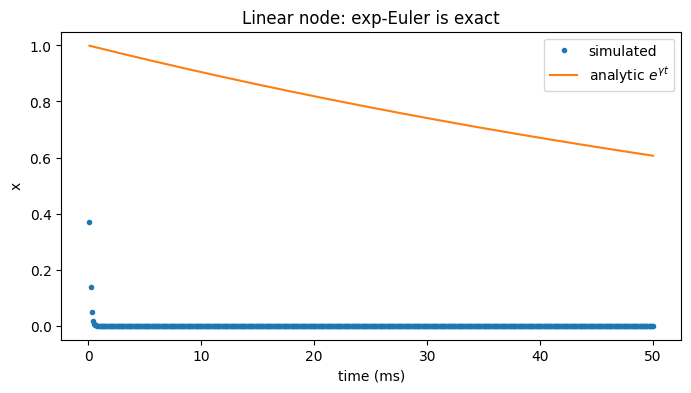

In [4]:
ts = u.get_magnitude(res['ts'])
x = u.get_magnitude(res['x'])[:, 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, x, 'o', ms=3, label='simulated')
ax.plot(ts, np.exp(-10.0 * ts / 1000.0), '-', label=r'analytic $e^{\gamma t}$')
ax.set_xlabel('time (ms)'); ax.set_ylabel('x'); ax.legend()
ax.set_title('Linear node: exp-Euler is exact')
plt.show()

## Try it: vary the decay rate `gamma`

More negative `gamma` means faster decay (shorter time constant $\tau = -1/\gamma$). With a constant drive the node would instead settle at $-c/\gamma$.

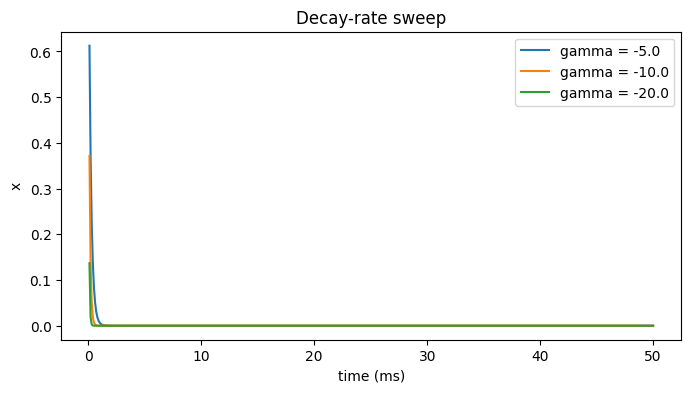

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for gamma in [-5.0, -10.0, -20.0]:
    m = brainmass.LinearStep(in_size=1, gamma=gamma)
    brainstate.nn.init_all_states(m)
    m.x.value = m.x.value + 1.0
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        50. * u.ms, monitors=['x'], init_states=False)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['x'])[:, 0], label=f'gamma = {gamma}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('x'); ax.legend()
ax.set_title('Decay-rate sweep')
plt.show()